---
title: Capella Processing Workflow
description: This notebook demonstrates the complete workflow for downloading and processing Capella SAR imagery using the `disasters-product-algorithms` package. 
author: 
  - Ethan Kerr (Editor, UAH)
  - Kyle Lesinger (Editor, UAH)
date: May 22, 2026
execute:
   freeze: true
---

# Run This Notebook

<div class="alert alert-block" style="
     background-color: #f8d7da;
     color: #721c24;
     border-left: 4px solid #28a745;
  ">
Disclaimer: it is highly recommended to run a tutorial within NASA VEDA JupyterHub, which already includes functions for processing and visualizing data specific to VEDA stories. Running the tutorial outside of the VEDA JupyterHub may lead to errors, specifically related to EarthData authentication. Additionally, it is recommended to use the Pangeo workspace within the VEDA JupyterHub, since certain packages relevant to this tutorial are already installed. </div>

<h4> If you <strong>do not</strong> have a VEDA Jupyterhub Account you can launch this notebook on your local environment using MyBinder by clicking the icon below.</h4>
<br/>
<a href="https://binder.openveda.cloud/v2/gh/NASA-IMPACT/veda-docs/9c8cdbae92906fb7062b8a0c759dad90e223a4f9?urlpath=lab%2Ftree%2Fuser-guide%2Fnotebooks%2Fstories%2Fderechos.ipynb">
<img src="https://binder.openveda.cloud/badge_logo.svg" alt="Binder" title="A cute binder" width="150"/> </a>

## Table of Contents
- [Capella Processing Workflow](#capella-processing-workflow)
- [Environment Setup](#environment-setup)
- [Process Capella Data](#process-capella-data)
- [View Results](#view-results)
- [Interactive Visualization](#interactive-visualization)
- [Next Steps](#next-steps)

# Capella Processing Workflow #

This notebook demonstrates the complete workflow for downloading and processing Capella imagery using the `disasters-product-algorithms` package.

## Workflow Steps
1. **Configure Environment Variables** - Set processing parameters
2. **Process Umbra Data** - Generate products with COG conversion and optional filtering
3. **View Results** - Examine the generated outputs

## Features Demonstrated
- Cloud Optimized GeoTIFF (COG) conversion
- Product Generation (Sigma)
- Filtering extreme high/low pixel values

# Environment Setup #

Configure all processing parameters as environment variables for easy modification.

In [1]:
# Activation event metadata
EVENT_NAME = '202406_Example_Event'    # YYYYMM_Hazard_Location
SOURCE = "CSDA"  # Data origin (e.g., USGS, Copernicus, CSDA, TBD)

import os
import subprocess

# Capella date format
DATE = "20260418193305" # YYYYMMDDHHMMSS

# Capella currently supports only sigma (extendable later)
PRODUCTS = {
    "sigma": True
}

# Filter control
FILTERS = {
    "sigma": True
}

FILTER_SIZE = 3

OUTPUT_DIR = "/tmp/s3_temp"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# COG options
COMPRESSION = "ZSTD"
COMPRESSION_LEVEL = 22
NODATA = 0

# Target CRS for the output COG.
# None preserves the source projection (fastest, no warp).
# Uncomment the EPSG:3857 line if you plan to push the COG through
# veda-data-airflow's build_stac, which trips on the EPSG:4326 ensemble.
TARGET_CRS = None
# TARGET_CRS = "EPSG:3857"

print("Configuration:")
print(f"  Date: {DATE}")
print(f"  Product: {PRODUCTS}")
print(f"  Output Directory: {OUTPUT_DIR}")

Configuration:
  Date: 20260418193305
  Product: {'sigma': True}
  Output Directory: /tmp/s3_temp


In [ ]:
from shared_utils import PROCESSOR_STRING
ACTIVATION_METADATA = {
    "ACTIVATION_EVENT": EVENT_NAME,
    "SOURCE": SOURCE,
    "PROCESSOR": PROCESSOR_STRING,
    # Add any custom key-value pairs here
}

# Write ACTIVATION_METADATA to a temp JSON file so the CLI can read it
# via --metadata-json and embed the tags onto each output COG.
import json, os, tempfile
_meta_fd, ACTIVATION_METADATA_PATH = tempfile.mkstemp(
    prefix='activation_meta_', suffix='.json'
)
with os.fdopen(_meta_fd, 'w') as _f:
    json.dump(ACTIVATION_METADATA, _f)


# Process Capella Data #

Process the downloaded imagery to generate various products with COG conversion and event naming.

**Note:** The processing script has been configured to display progress in real-time within JupyterHub. You'll see:
- Detailed product generation steps
- COG conversion progress
- Error messages if any products fail
- Final processing summary with success/failure counts
- Log file location for detailed error tracking

In [2]:
process_cmd = [
    "process_capella",
    "-h"
]

help_flags = subprocess.run(process_cmd, cwd=os.getcwd())
print(help_flags)

usage: process_capella [-h] --product {sigma} [--apply_filter]
                       [--filter_size FILTER_SIZE] --date DATE
                       [--prefix PREFIX] [--bucket BUCKET] [--output OUTPUT]
                       [-nodata NODATA] [-compression COMPRESSION]
                       [-compression_level COMPRESSION_LEVEL]
                       [-dst_crs DST_CRS]

Process Capella imagery

options:
  -h, --help            show this help message and exit
  --product {sigma}     Calibration product to generate
  --apply_filter        Apply Lee filtering
  --filter_size FILTER_SIZE
                        Lee filter window size
  --date DATE           Target date (YYYYMMDDHHMMSS)
  --prefix PREFIX       S3 prefix
  --bucket BUCKET       S3 bucket
  --output OUTPUT       Output directory
  -nodata NODATA        No-data value for COG outputs
  -compression COMPRESSION
                        Compression type for COG
  -compression_level COMPRESSION_LEVEL
                        Compr

In [3]:
for PRODUCT, ENABLED in PRODUCTS.items():

    if not ENABLED:
        continue

    process_cmd = [
        "process_capella",
        "--product", PRODUCT,
        "--date", DATE,
        "--output", OUTPUT_DIR,
        "-compression", COMPRESSION,
        "-compression_level", str(COMPRESSION_LEVEL),
        "-dst_crs", TARGET_CRS if TARGET_CRS else "native",
    ]

    if NODATA is not None:
        process_cmd.extend(["-nodata", str(NODATA)])

    if FILTERS.get(PRODUCT, False):
        process_cmd.append("--apply_filter")
        process_cmd.extend(["--filter_size", str(FILTER_SIZE)])

    print(f"Processing Capella data: {PRODUCT}...")
    print(f"Command: {' '.join(process_cmd)}\n")

    process_cmd.extend(["--metadata-json", ACTIVATION_METADATA_PATH])
    process = subprocess.Popen(
        process_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True,
        bufsize=1
    )

    for line in process.stdout:
        print(line, end="")

    return_code = process.wait()

    if return_code == 0:
        print("\n✓ Capella processing completed successfully!\n")
    else:
        print(f"\n✗ Capella processing failed with return code {return_code}\n")

Processing Capella data: sigma...
Command: process_capella --product sigma --date 20260418193305 --output /tmp/s3_temp -compression ZSTD -compression_level 22 -dst_crs native -nodata 0 --apply_filter --filter_size 3

/srv/conda/envs/notebook/lib/python3.12/site-packages/capella/capella_v2.py:145: RuntimeWarning: divide by zero encountered in log10
  sigma_0 = 20.0 * np.log10(scale_factor * dn)
Retrieving Capella resources...
GEO file not found, downloading from S3
Generating Sigma Naught

	* Opening GEO File
DN range: 0 -> 65535
Scale factor: 0.0003869981737807393
Sigma0 range: -60.0 -> 28.083644387630564
Generation completed, file saved to /tmp/s3_temp/202604_Capella-18_sigma02026-04-18T19:33:05Z.tif
Applying Lee filter (size=3)
Filtered file written to /tmp/s3_temp/202604_Capella-18_sigma02026-04-18T19:33:05Z_filtered.tif

Converting to COG...
  Data type: float32
  No-data value: 0.0
  Source CRS: EPSG:32655
  Compression: ZSTD (level 22)
  Overview levels: 5
  Creating COG: 202604_

# View Results #

Examine the generated output files and directory structure.

✓ Found output directory: /tmp/s3_temp

Displaying 1 product groups...


Displaying: 202604_Capella-18_sigma02026-04-18T19:33:05Z_filtered.tif
202604_Capella-18_sigma02026-04-18T19:33:05Z_filtered.tif min: -18.0 max: -3.0 mean: -13.10570853968211 std: 5.994289599128577


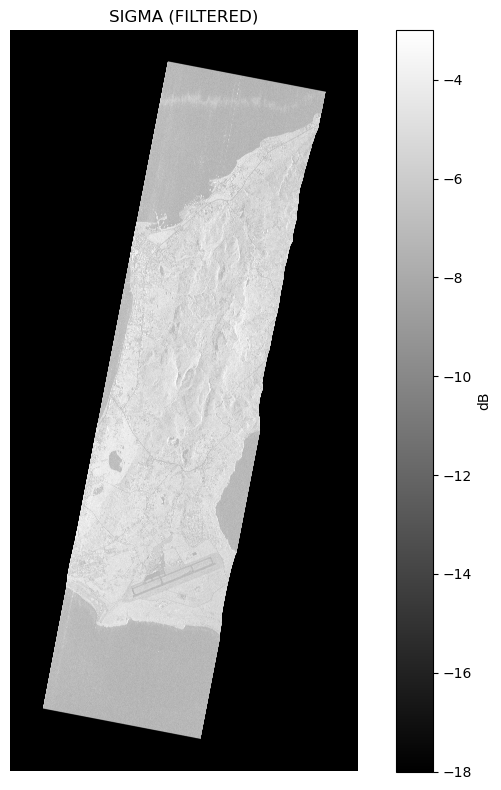

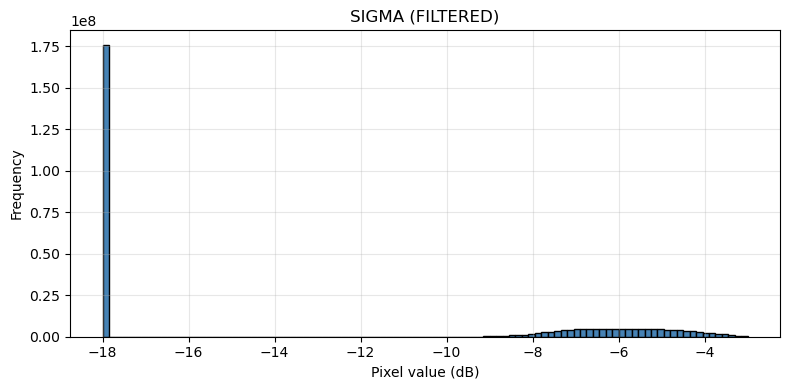

✓ Plotted 202604_Capella-18_sigma02026-04-18T19:33:05Z_filtered.tif

Displaying: CAPELLA_C18_SM_GEO_HH_20260418193305_20260418193309.tif
CAPELLA_C18_SM_GEO_HH_20260418193305_20260418193309.tif min: 0.0 max: 65535.0 mean: 189.16567284149704 std: 382.3989225746988


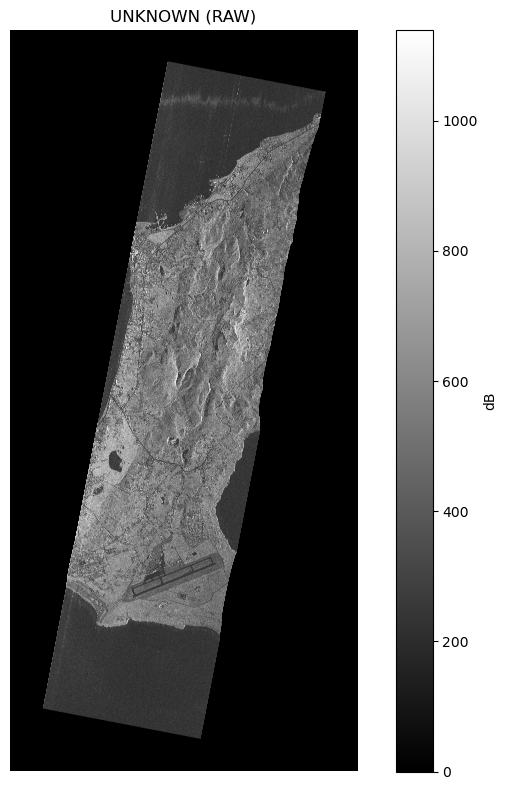

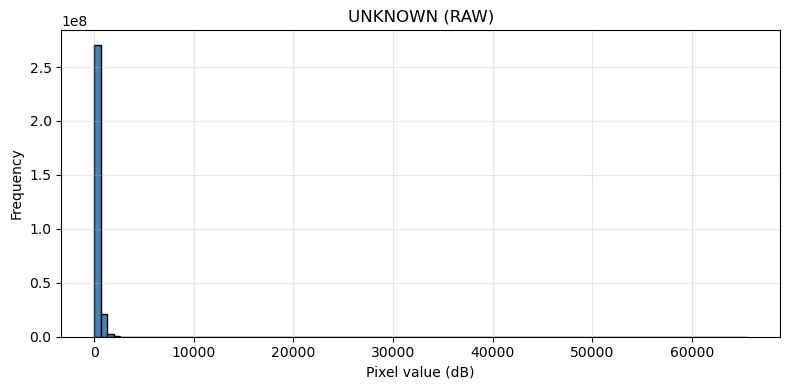

✓ Plotted CAPELLA_C18_SM_GEO_HH_20260418193305_20260418193309.tif

File Details:

s3_temp:
  - 2026-01-28-17-38-00_UMBRA-10_GEC.tif (584.3 MB)
  - 202601_Umbra-10_beta02026-01-28T17:38:00Z_filtered.tif (1167.1 MB)
  - 202601_Umbra-10_sigma02026-01-28T17:38:00Z_filtered.tif (1167.1 MB)
  - 20260424_224158_273_SN46_L1D_SR_MS_CLOUD_0.tif (4.4 MB)
  - 20260424_224158_273_SN46_L1D_SR_MS_TOA_0.tif (2085.7 MB)
  - 202604_Capella-18_sigma02026-04-18T19:33:05Z_filtered.tif (520.6 MB)
  - CAPELLA_C18_SM_GEO_HH_20260418193305_20260418193309.tif (232.3 MB)


In [9]:
import glob
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

output_dir = os.path.abspath(OUTPUT_DIR)


def parse_product_name(filename):
    name = filename.lower()

    if "sigma0" in name:
        return "sigma"
    else:
        return "unknown"


def get_cmap(product):
    return "gray"


if output_dir:

    print(f"✓ Found output directory: {output_dir}\n")

    tif_files = sorted([
        f for f in glob.glob(
            os.path.join(output_dir, "**/*.tif"),
            recursive=True
        )
        if not f.endswith(".tmp.tif")
    ])

    if tif_files:

        product_types = {}

        for tif_file in tif_files:
            product_type = os.path.basename(os.path.dirname(tif_file))
            product_types.setdefault(product_type, []).append(tif_file)

        print(f"Displaying {len(product_types)} product groups...\n")

        for tif_file in tif_files:

            if 'capella' in tif_file.lower():
                print(f"\nDisplaying: {os.path.basename(tif_file)}")
    
                product = parse_product_name(tif_file)
                cmap = get_cmap(product)
    
                is_filtered = "filt" in tif_file.lower()
    
                with rasterio.open(tif_file) as src:
                    arr = src.read(1).astype(float)
    
                    print(
                        os.path.basename(tif_file),
                        "min:", np.nanmin(arr),
                        "max:", np.nanmax(arr),
                        "mean:", np.nanmean(arr),
                        "std:", np.nanstd(arr)
                    )
    
                    plt.figure(figsize=(8, 8))
    
                    # Percentile stretch for raw GEC
                    if product.upper() == 'UNKNOWN':
                        vmin, vmax = np.nanpercentile(arr, (2, 98))
                    else:
                        vmin, vmax = np.nanpercentile(arr, (0, 100))
    
                    im = plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
                    
                    cbar = plt.colorbar(im)
                    cbar.set_label("dB")
    
                    title = (
                        f"{product.upper()} "
                        f"{'(FILTERED)' if is_filtered else '(RAW)'}"
                    )
    
                    plt.title(title)
                    plt.axis("off")
                    plt.tight_layout()
                    plt.show()
    
                    # Histogram
                    valid = arr[np.isfinite(arr)]
    
                    plt.figure(figsize=(8, 4))
    
                    plt.hist(
                        valid.flatten(),
                        bins=100,
                        color="steelblue",
                        edgecolor="black"
                    )
    
                    plt.title(title)
                    plt.xlabel("Pixel value (dB)")
                    plt.ylabel("Frequency")
    
                    plt.grid(alpha=0.3)
                    plt.tight_layout()
                    plt.show()
    
                    print(f"✓ Plotted {os.path.basename(tif_file)}")
            else:
                continue

        print("\nFile Details:")
        print("=" * 50)

        for p_type, files in sorted(product_types.items()):

            print(f"\n{p_type}:")

            for f in files:

                size = os.path.getsize(f) / (1024 * 1024)

                print(
                    f"  - {os.path.basename(f)} "
                    f"({size:.1f} MB)"
                )

    else:
        print("No finished GeoTIFF files found. Check processing output.")

else:
    print("Output directory not found.")

# Interactive Visualization

Using the leafmap package, we can visualize a file on a map projection with pan and zoom capabilities. With this, we can see the high-resolution details of Capella, analyze the effects of the lee filter (which smoothes data), and view the geolocation of the file.

In [5]:
! pip install leafmap
! pip install localtileserver

  Using cached leafmap-0.62.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached duckdb-1.5.3-cp312-cp312-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
  Using cached gdown-6.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached geojson-3.2.0-py3-none-any.whl.metadata (16 kB)
  Using cached ipyfilechooser-0.6.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached ipyvue-1.12.0-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached ipyvuetify-1.11.3-py2.py3-none-any.whl.metadata (7.5 kB)
  Using cached maplibre-0.3.6-py3-none-any.whl.metadata (4.2 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached python_box-7.4.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
  Using cached scooby-0.11.2-py3-none-any.whl.metadata (16 kB)
  Using cached whiteboxgui-2.3.0-py2.py3-none-any.whl.metadata (5.7 kB)
  Using cached eval_type_backport-0.3.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached whiteb

In [7]:
import leafmap
m = leafmap.Map()
m.add_raster(tif_files[0], layer_name="SAR") # adjust index in tif_files[_] to change file being viewed
m

Map(center=[15.1695875, 145.731896], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

# Next Steps #

You can now:
1. Load and visualize the GeoTIFF files using libraries like `rasterio` or `GDAL`
2. Upload the COG files to cloud storage (S3, GCS, etc.)
3. Process additional dates or tiles by modifying the configuration variables